# 모바일 주변 소음 정보 (mAmbience) 심층 EDA

이 노트북은 `ch2025_mAmbience.parquet` 내의 중첩 소음 분류 데이터를 평탄화(Flatten)하여 분석합니다.

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 테마 설정 시 폰트 정보를 함께 주입하여 덮어쓰기 방지 (Windows/Mac/Linux 대응)
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Malgun Gothic",
            "AppleGothic",
            "NanumGothic",
            "DejaVu Sans",
            "Arial",
            "Helvetica",
            "sans-serif",
        ],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["figure.figsize"] = (12, 6)

# 현재 스크립트/노트북 위치 기준의 절대 경로 기준점 정의 (어디서 실행해도 경로 에러 방지)
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()

DATA_PATH = os.path.join(BASE_DIR, "../../data/ch2025_data_items/ch2025_mAmbience.parquet")
df = pd.read_parquet(DATA_PATH)

## 1. 데이터 구조 및 중첩 확인

In [8]:
print(f"데이터 크기 (Shape): {df.shape}")
df.head()

데이터 크기 (Shape): (476577, 3)


,subject_id,timestamp,m_ambience
0,id01,2024-06-26 13:00:10,"[[Music, 0.30902618], [Vehicle, 0.081680894], ..."
1,id01,2024-06-26 13:02:10,"[[Music, 0.62307084], [Vehicle, 0.021118319], ..."
2,id01,2024-06-26 13:04:10,"[[Horse, 0.25209898], [Animal, 0.24263993], [C..."
3,id01,2024-06-26 13:06:10,"[[Speech, 0.93433166], [Inside, large room or ..."
4,id01,2024-06-26 13:08:10,"[[Speech, 0.8935082], [Inside, small room, 0.0..."


## 2. 데이터 평탄화 (Flatten) 및 상위 사운드 분석
각 행의 `m_ambience` 어레이 내에 있는 클래스와 신뢰도 점수를 추출합니다.

In [9]:
# Vectorized explode를 사용하여 전체 데이터(약 47만 행)를 초고속으로 평탄화
flat_df = df.explode("m_ambience").dropna(subset=["m_ambience"])
flat_df["sound_class"] = flat_df["m_ambience"].str[0]
flat_df["confidence"] = flat_df["m_ambience"].str[1].astype(float)
flat_df = flat_df.drop(columns=["m_ambience"])

print(f"평탄화된 전체 사운드 데이터 크기: {flat_df.shape}")
flat_df.head()

평탄화된 전체 사운드 데이터 크기: (4765770, 4)


,subject_id,timestamp,sound_class,confidence
0,id01,2024-06-26 13:00:10,Music,0.309026
0,id01,2024-06-26 13:00:10,Vehicle,0.081681
0,id01,2024-06-26 13:00:10,Motor vehicle (road),0.040353
0,id01,2024-06-26 13:00:10,"Outside, urban or manmade",0.037144
0,id01,2024-06-26 13:00:10,"Outside, rural or natural",0.032663


### 2.1 신뢰도 임계값(0.3 이상) 기준 가장 많이 감지된 사운드 TOP 15
저조도 배경 잡음을 필터링하기 위해 신뢰 점수 0.3 이상인 이벤트만 집계합니다. (지배적인 'Silence' 제외)

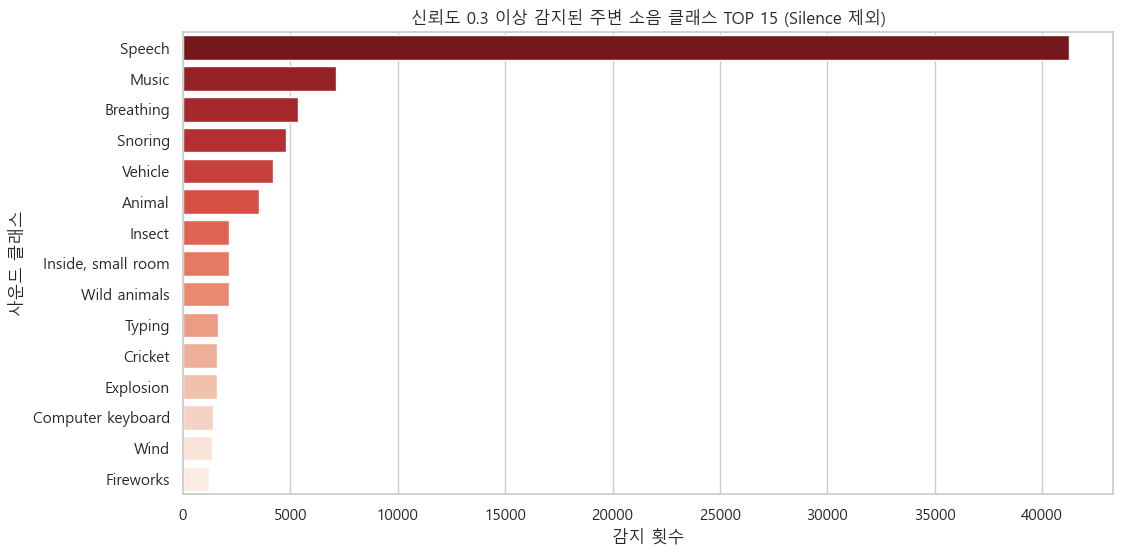

In [10]:
high_conf_df = flat_df[flat_df["confidence"] >= 0.3]
top_sounds = high_conf_df[high_conf_df["sound_class"] != "Silence"]["sound_class"].value_counts().head(15).reset_index()
top_sounds.columns = ["sound_class", "count"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sounds, x="count", y="sound_class", hue="sound_class", palette="Reds_r", legend=False)
plt.title("신뢰도 0.3 이상 감지된 주변 소음 클래스 TOP 15 (Silence 제외)")
plt.xlabel("감지 횟수")
plt.ylabel("사운드 클래스")
plt.show()

### 2.2 참여자별 주요 신뢰 사운드(Confidence >= 0.3) 분포 비교
참여자별로 생활 환경 및 개인 특성을 보여주는 주요 사운드 클래스의 점유 횟수를 비교합니다.

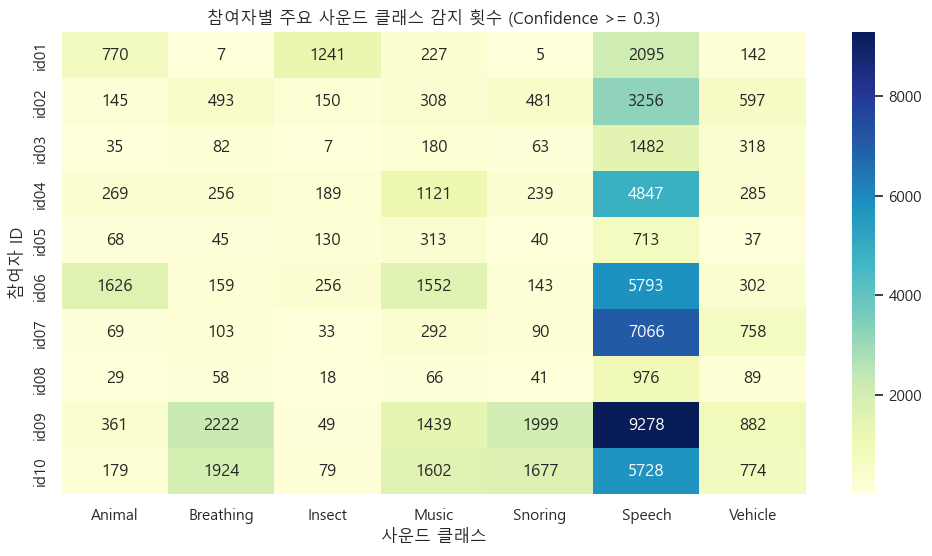

sound_class,Animal,Breathing,Insect,Music,Snoring,Speech,Vehicle
subject_id,,,,,,,
id01,770,7,1241,227,5,2095,142
id02,145,493,150,308,481,3256,597
id03,35,82,7,180,63,1482,318
id04,269,256,189,1121,239,4847,285
id05,68,45,130,313,40,713,37
id06,1626,159,256,1552,143,5793,302
id07,69,103,33,292,90,7066,758
id08,29,58,18,66,41,976,89
id09,361,2222,49,1439,1999,9278,882


In [11]:
target_classes = ["Speech", "Music", "Vehicle", "Breathing", "Snoring", "Insect", "Animal"]
sub_sound_df = high_conf_df[high_conf_df["sound_class"].isin(target_classes)]
sub_sound_pivot = pd.crosstab(sub_sound_df["subject_id"], sub_sound_df["sound_class"])

plt.figure(figsize=(12, 6))
sns.heatmap(sub_sound_pivot, annot=True, cmap="YlGnBu", fmt="d")
plt.title("참여자별 주요 사운드 클래스 감지 횟수 (Confidence >= 0.3)")
plt.xlabel("사운드 클래스")
plt.ylabel("참여자 ID")
plt.show()
sub_sound_pivot

### 2.3 평균 신뢰도가 높은 사운드 분석

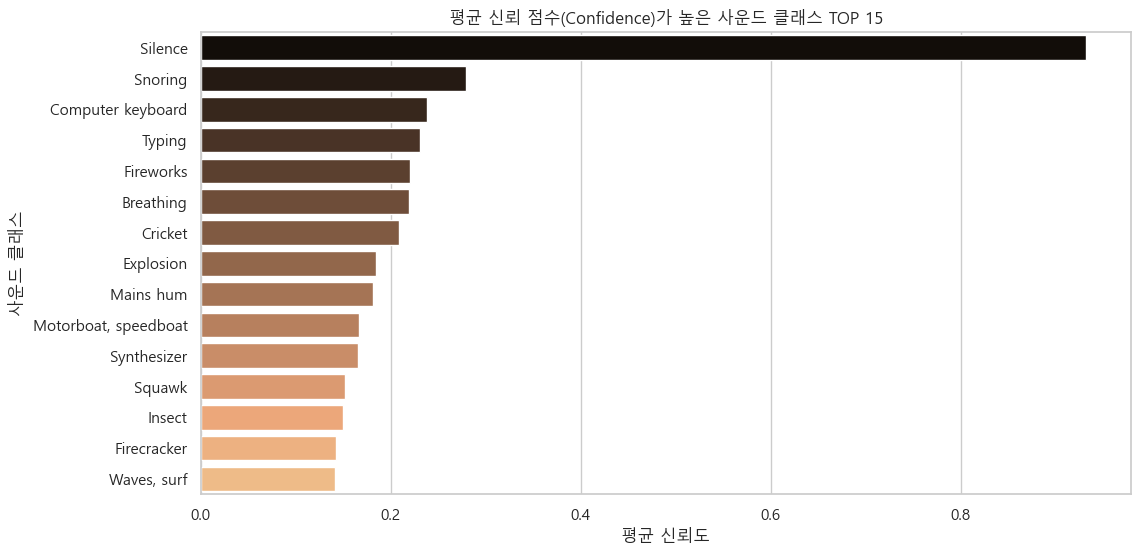

In [12]:
mean_conf = flat_df.groupby("sound_class")["confidence"].agg(["count", "mean"]).reset_index()
# 최소 100회 이상 감지된 소리 대상
mean_conf = mean_conf[mean_conf["count"] >= 100].sort_values(by="mean", ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=mean_conf, x="mean", y="sound_class", hue="sound_class", palette="copper", legend=False)
plt.title("평균 신뢰 점수(Confidence)가 높은 사운드 클래스 TOP 15")
plt.xlabel("평균 신뢰도")
plt.ylabel("사운드 클래스")
plt.show()

## 3. 시간대별 말소리(Speech) vs 침묵(Silence) 분석
사용자가 활발히 소통하는 시간대와 조용한 시간대를 시각화합니다.

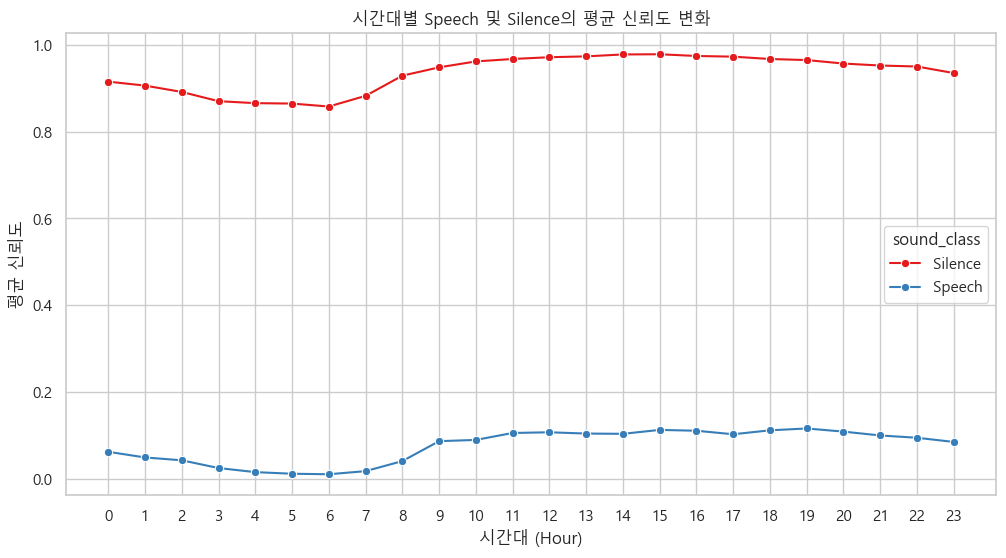

In [13]:
flat_df["hour"] = flat_df["timestamp"].dt.hour
speech_silence = flat_df[flat_df["sound_class"].isin(["Speech", "Silence"])]
hourly_sound = speech_silence.groupby(["hour", "sound_class"])["confidence"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_sound, x="hour", y="confidence", hue="sound_class", marker="o", palette="Set1")
plt.title("시간대별 Speech 및 Silence의 평균 신뢰도 변화")
plt.xlabel("시간대 (Hour)")
plt.ylabel("평균 신뢰도")
plt.xticks(range(0, 24))
plt.show()

## 4. 피처 엔지니어링 제안
* **`amb_speech_mean`**: 하루 중 Speech 클래스의 평균 신뢰도 (사회적 상호작용 피처).
* **`amb_music_mean`**: 하루 중 Music 클래스의 평균 신뢰도 (여가 활동 지표).
* **`amb_silence_ratio`**: 하루 중 침묵 상태가 감지된 비율 (환경 평온도 지표).